In [1]:
import pandas as pd
import numpy as np
import hashlib
from collections import Counter
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Load incident data

In [2]:
df_incident = pd.read_csv('Data/fair-drg-1066-incidence-database-43456-3229/incidence_db_00002.csv')

In [3]:
df_incident = df_incident[['householdid', 'particid', 'f_date', 'death_date', 'f_mci', 'gender', 'centreid']]
df_incident

,householdid,particid,f_date,death_date,f_mci,gender,centreid
0,1.0,1,NaN,2005-08-10,NaN,1.0,1
1,NaN,2,2007-12-05,NaN,0.0,2.0,1
2,2.0,1,2007-12-12,NaN,1.0,1.0,1
3,3.0,1,NaN,NaN,NaN,1.0,1
4,NaN,2,NaN,2005-02-25,NaN,2.0,1
...,...,...,...,...,...,...,...
12860,NaN,2,2013-11-20,NaN,0.0,1.0,20
12861,10267.0,1,NaN,2012-11-15,NaN,1.0,20
12862,10268.0,1,2012-05-15,NaN,0.0,1.0,20
12863,10269.0,1,NaN,NaN,NaN,1.0,20


In [4]:
df_incident.death_date.isna().sum()

11095

In [5]:
{1.0: 'Cuba',
  2.0: 'DR',
  3.0: 'Peru (urban)',
  4.0: 'Peru (rural)',
  5.0: 'Venezuela',
  6.0: 'Mexico (urban)',
  7.0: 'Mexico (rural)',
  8.0: 'Argentina (urban)',
  9.0: 'Argentina (urban)',
  10.0: 'China (urban)',
  11.0: 'China (rural)',
  12.0: 'India (urban)',
  13.0: 'India (rural)',
  14.0: 'Nigeria',
  20.0: 'Puerto Rico'}

{1.0: 'Cuba',
 2.0: 'DR',
 3.0: 'Peru (urban)',
 4.0: 'Peru (rural)',
 5.0: 'Venezuela',
 6.0: 'Mexico (urban)',
 7.0: 'Mexico (rural)',
 8.0: 'Argentina (urban)',
 9.0: 'Argentina (urban)',
 10.0: 'China (urban)',
 11.0: 'China (rural)',
 12.0: 'India (urban)',
 13.0: 'India (rural)',
 14.0: 'Nigeria',
 20.0: 'Puerto Rico'}

In [6]:
# Replacement dictionary
centreid_dict = {
  1: "Cuba",
  2: "DR",
  3: "Peru (urban)",
  4: "Peru (rural)",
  5: "Venezuela",
  6: "Mexico (urban)",
  7: "Mexico (rural)",
  8: "Argentina (urban)",
  9: "Argentina (urban)",
  10: "China (urban)",
  11: "China (rural)",
  12: "India (urban)",
  13: "India (rural)",
  20: "Puerto Rico",
  21: "Nigeria"
}

# Apply mapping
df_incident['Countries'] = df_incident['centreid'].map(centreid_dict)

In [7]:
Counter(df_incident['centreid'])

Counter({1: 2944,
         2: 2011,
         3: 1381,
         5: 1965,
         7: 1000,
         20: 2009,
         4: 552,
         6: 1003})

In [8]:
Counter(df_incident['Countries'])

Counter({'Cuba': 2944,
         'DR': 2011,
         'Peru (urban)': 1381,
         'Venezuela': 1965,
         'Mexico (rural)': 1000,
         'Puerto Rico': 2009,
         'Peru (rural)': 552,
         'Mexico (urban)': 1003})

# Load BBAG data

In [9]:
results_GB_orig = pd.read_parquet('Results/wo-used-diag-vars-and-funct-vars_all-subjects.parquet')

In [10]:
results_GB_orig.anydem.value_counts()

anydem
0.0    11461
1.0     1223
Name: count, dtype: int64

## Matching

In [11]:
#results_GB_orig = pd.read_excel('Results/results_GB_extravars.xlsx')

In [12]:
import numpy as np
import hashlib

def make_generic_id(row):
  h = row['householdid']
  p = row['particid']
  def to_str(val):
    if pd.isna(val): return ""
    if isinstance(val, float) and val.is_integer(): return str(int(val))
    return str(val)
  if pd.isna(h) or pd.isna(p): return np.nan
  uid_str = to_str(h) + "_" + to_str(p)
  return 'SUBJ_' + hashlib.md5(uid_str.encode()).hexdigest()[:8]

df_incident['generic_id'] = df_incident.apply(make_generic_id, axis=1)

In [13]:
df_incident[["householdid", "particid", "generic_id"]]

In [14]:
results_GB_orig[["generic_id"]]

In [15]:
# (optional) see how many valid IDs you have
print(df_incident["generic_id"].notna().mean(), results_GB_orig["generic_id"].notna().mean())

# drop original ids to anonymize
df_incident = df_incident.drop(columns=['householdid', 'particid'])

# matching
matched = df_incident.merge(results_GB_orig, on="generic_id", how="inner", suffixes=("_inc", "_gb"))

# Define death and end date, and event


## I dont consider alive participant without f_date anda death_date

### All subjects

In [16]:
matched = df_incident.merge(results_GB_orig, on="uid", how="inner", suffixes=("_inc", "_gb"))

matched["date"] = pd.to_datetime(matched["date"], errors="coerce")
matched["death_date"] = pd.to_datetime(matched["death_date"], errors="coerce")
matched["f_date"] = pd.to_datetime(matched["f_date"], errors="coerce")


matched["event"] = matched["death_date"].notna().astype(int)

# End date:
# - if died -> death_date
# - if not died -> f_date (last evaluation)
matched["end_date"] = matched["death_date"].fillna(matched["f_date"])

# (Optional, in case any end_date is empty)
matched["end_date"] = matched["end_date"].fillna(matched["date"].max())

# Time in years
matched["time_years"] = (matched["end_date"] - matched["date"]).dt.days / 365.25

# (Optional) mark invalid times as NaN
matched.loc[matched["time_years"] < 0, "time_years"] = np.nan
matched.loc[matched["time_years"] > 5.5, "time_years"] = np.nan

In [17]:
#a = matched[["date", "death_date", "f_date","end_date", "event"]].dropna(subset = ["f_date"])#['event']#.value_counts()

In [18]:
#a[a.event == 1]

In [19]:
matched

,householdid_inc,particid_inc,f_date,death_date,f_mci,gender,centreid_inc,Countries_inc,uid,particid_gb,...,orthostatic_drop,pulse_pressure,y_labels,y_pred,GAP,GAP_corrected,y_pred_corrected,event,end_date,time_years
0,1.0,1,NaT,2005-08-10,NaN,1.0,1,Cuba,1_1,1,...,1.073333,37.333333,72.0,74.880673,2.880673,1.020028,73.020028,1,2005-08-10,1.930185
1,2.0,1,2007-12-12,NaT,1.0,1.0,1,Cuba,2_1,1,...,0.984615,47.666667,65.0,70.201979,5.201979,-2.512345,62.487655,0,2007-12-12,4.279261
2,3.0,1,NaT,NaT,NaN,1.0,1,Cuba,3_1,1,...,1.028986,130.000000,87.0,76.319927,-10.680073,-0.909823,86.090177,0,2009-11-16,NaN
3,4.0,1,2008-06-25,NaT,0.0,1.0,1,Cuba,4_1,1,...,0.954545,41.666667,73.0,70.992205,-2.007795,-3.108889,69.891111,0,2008-06-25,4.717317
4,5.0,1,NaT,NaT,NaN,1.0,1,Cuba,5_1,1,...,1.027778,49.666667,77.0,74.922693,-2.077307,0.006394,77.006394,0,2009-11-16,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10136,10266.0,1,2013-05-08,NaT,0.0,1.0,20,Puerto Rico,10266_1,1,...,0.994987,50.666667,70.0,77.314570,7.314570,3.818806,73.818806,0,2013-05-08,3.874059
10137,10267.0,1,NaT,2012-11-15,NaN,1.0,20,Puerto Rico,10267_1,1,...,1.214452,86.666667,83.0,80.753274,-2.246726,4.505569,87.505569,1,2012-11-15,3.397673
10138,10268.0,1,2012-05-15,NaT,0.0,1.0,20,Puerto Rico,10268_1,1,...,0.974359,88.666667,99.0,75.618934,-23.381066,-3.888169,95.111831,0,2012-05-15,2.893908
10139,10269.0,1,NaT,NaT,NaN,1.0,20,Puerto Rico,10269_1,1,...,1.012493,56.984116,84.0,75.130092,-8.869908,-1.158032,82.841968,0,2009-11-16,2.242300


In [20]:
import matplotlib.pyplot as plt
def forest_plot_gap(cph_unadj, cph_adj,
          color_unadj="#2196F3", color_adj="#E53935",
          gap_var="GAP_z", save_path=None):

  def extract_gap(cph):
    out = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
    out.columns = ["HR", "CI_low", "CI_high", "p_value"]
    return out.loc[gap_var]

  row_u = extract_gap(cph_unadj)
  row_a = extract_gap(cph_adj)

  models   = ["Unadjusted", "Adjusted"]
  rows    = [row_u, row_a]
  colors   = [color_unadj, color_adj]
  markers   = ["s", "o"]     # <-- square / circle
  y_positions = [1, 0]

  fig, ax = plt.subplots(figsize=(6, 2.5))

  for model, row, color, marker, y in zip(models, rows, colors, markers, y_positions):
    ax.plot([row["CI_low"], row["CI_high"]], [y, y],
        color=color, linewidth=2.0, zorder=2)
    ax.plot(row["HR"], y, marker=marker, color=color,
        ms=9, zorder=3, linestyle="None")

    p = row["p_value"]
    p_str = "p<0.001" if p < 0.001 else f"p={p:.3f}"
    ax.text(row["CI_high"] + 0.01, y,
        f"HR={row['HR']:.3f} [{row['CI_low']:.3f}–{row['CI_high']:.3f}] {p_str}",
        va="center", fontsize=8, color=color)

  ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.8, zorder=1)
  ax.set_yticks(y_positions)
  ax.set_yticklabels(models, fontsize=9)
  ax.set_xlabel("Hazard Ratio (95% CI)", fontsize=9)
  ax.set_title(f"Forest Plot — {gap_var}", fontsize=10, fontweight="bold")
  ax.set_ylim(-0.5, 1.5)
  ax.set_xlim(0.95, 1.7)
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  plt.tight_layout()

  if save_path:
    plt.savefig(save_path, format="pdf", bbox_inches="tight", dpi=300)
    print(f" Saved: {save_path}")

  plt.show()

#### Cox model

In [21]:
from lifelines import CoxPHFitter


df_surv = matched[['time_years', 'event', 'GAP_corrected']].dropna()

cph = CoxPHFitter().fit(df_surv, duration_col='time_years', event_col='event')

out = cph.summary.loc[['GAP_corrected'], ['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']]
out = out.rename(columns={
  'exp(coef)': 'HR',
  'exp(coef) lower 95%': 'CI95_low',
  'exp(coef) upper 95%': 'CI95_high',
  'p': 'p_value'
})
out


,HR,CI95_low,CI95_high,p_value
covariate,,,,
GAP_corrected,1.147903,1.128967,1.167157,2.127464e-59


In [22]:
covars = ['Age', 'Male', 'Education']


In [23]:
from lifelines import CoxPHFitter

def compact_all(cph):
  out = cph.summary.loc[:, ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
  out.columns = ["HR", "CI95_low", "CI95_high", "p_value"]
  return out.sort_values("p_value")




In [24]:
from lifelines import CoxPHFitter

matched["Male"] = (matched["Sex_1F_2M"] == 2).astype(int)



matched["GAP_z"] = (matched["GAP_corrected"] - matched["GAP_corrected"].mean()) / matched["GAP_corrected"].std()

# Unadjusted (by 1 SD)
df_z_unadj = matched[["time_years", "event", "GAP_z"]].dropna()
cph_z_unadj = CoxPHFitter()
cph_z_unadj.fit(df_z_unadj, duration_col="time_years", event_col="event")
print("--- Cox GAP_z (UNADJUSTED) ---")
display(compact_all(cph_z_unadj))

# Adjusted (by 1 SD) using Male dummy
needed_cols_z = ["time_years", "event", "GAP_z"] + covars
df_z_adj = matched[needed_cols_z].dropna()
cph_z_adj = CoxPHFitter()
cph_z_adj.fit(df_z_adj, duration_col="time_years", event_col="event")
print("\n\n--- Cox GAP_z (ADJUSTED) ---")
display(compact_all(cph_z_adj))


✅ Guardado: Figures/Model-C_forest-plot_All-subjects.pdf


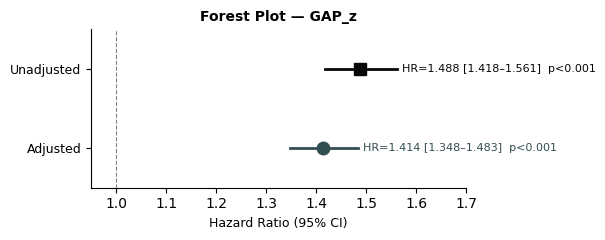

In [25]:
forest_plot_gap(cph_z_unadj, cph_z_adj,
        color_unadj="#090608",
        color_adj="#334E50",
        save_path="Figures/Model-C_forest-plot_All-subjects.pdf")

#### Meta analysis urban rural

In [26]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter

meta_results = []

matched_for_meta = matched.copy()

matched_for_meta['Countries_inc'] = matched_for_meta['Countries_inc'].replace({
  'Peru (urban)': 'Peru',
  'Peru (rural)': 'Peru',
  'Mexico (rural)': 'Mexico',
  'Mexico (urban)': 'Mexico',
  'DR': 'Dominican R.'
})

for country in matched_for_meta['Countries_inc'].dropna().unique():
  
  c_matched = matched_for_meta[matched_for_meta['Countries_inc'] == country].copy()
  
  c_matched["Male"] = (c_matched["Sex_1F_2M"] == 2).astype(int)
  
  # Standardize within country
  sd_gap = c_matched["GAP_corrected"].std()
  
  if pd.isna(sd_gap) or sd_gap == 0:
    print(f"Skipping {country}: GAP_corrected std is 0 or NaN")
    continue
  
  c_matched["GAP_z"] = (matched["GAP_corrected"] - c_matched["GAP_corrected"].mean()) / c_matched["GAP_corrected"].std()


  # Unadjusted Cox model
  df_z_unadj = c_matched[["time_years", "event", "GAP_z"]].dropna()
  
  n = len(df_z_unadj)
  n_events = df_z_unadj["event"].sum()
  
  # Skip countries with too little information
  if n < 10 or n_events < 3:
    print(f"Skipping {country}: too few observations or events (n={n}, events={n_events})")
    continue
  
  try:
    cph_z_unadj = CoxPHFitter()
    cph_z_unadj.fit(df_z_unadj, duration_col="time_years", event_col="event")
    
    row = cph_z_unadj.summary.loc["GAP_z"]
    
    meta_results.append({
      "country": country,
      "n": n,
      "events": n_events,
      "logHR": row["coef"],
      "HR": row["exp(coef)"],
      "SE": row["se(coef)"],
      "lower_CI": row["exp(coef) lower 95%"],
      "upper_CI": row["exp(coef) upper 95%"],
      "p_value": row["p"]
    })
    
    print(f"Done: {country}")
    
  except Exception as e:
    print(f"Error in {country}: {e}")

meta_df = pd.DataFrame(meta_results)
meta_df.to_csv('MetaAnalysis/Model-C-meta-table.csv')
display(meta_df)

Done: Cuba
Done: Dominican R.
Done: Peru
Done: Venezuela
Done: Mexico
Done: Puerto Rico


,country,n,events,logHR,HR,SE,lower_CI,upper_CI,p_value
0,Cuba,1955,437,0.418366,1.519477,0.040252,1.404207,1.644209,2.652040e-25
1,Dominican R.,1503,342,0.309900,1.363289,0.050321,1.235248,1.504601,7.347508e-10
2,Peru,1530,92,0.277163,1.319382,0.094401,1.096519,1.587540,3.324494e-03
3,Venezuela,1508,127,0.429478,1.536455,0.074228,1.328425,1.777062,7.210567e-09
4,Mexico,1604,111,0.495099,1.640661,0.080162,1.402119,1.919786,6.564768e-10
5,Puerto Rico,1427,196,0.446647,1.563063,0.067576,1.369166,1.784420,3.853629e-11


#### Survive curve

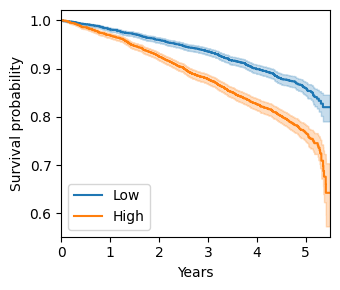

In [27]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt


matched["GAP_group"] = np.where(matched["GAP_corrected"] <= 0, "Low", "High")
matched["GAP_group_bin"] = np.where(matched["GAP_corrected"] <= 0, 0, 1)
matched["GAP_group"].value_counts(dropna=False)


kmf = KaplanMeierFitter()
plt.figure(figsize=(3.5,3.0))

for g in ["Low", "High"]:
  mask = matched["GAP_group"] == g
  df_g = matched.loc[mask, ["time_years", "event"]].dropna()
  kmf.fit(df_g["time_years"], df_g["event"], label=g)
  kmf.plot_survival_function(ci_show=True)

plt.xlabel("Years")
plt.ylabel("Survival probability")
#plt.title("Kaplan–Meier survival by GAP_corrected (≤0 vs >0)")
plt.tight_layout()
plt.xlim([0,5.5])


plt.savefig("Figures/Model-C_kaplan_meier_All-subjects.pdf", format="pdf", bbox_inches="tight", dpi=300)

plt.show()


#### Log rank

In [28]:
from lifelines.statistics import logrank_test

df_low = matched.loc[matched["GAP_group"]=="Low", ["time_years","event"]].dropna()
df_high = matched.loc[matched["GAP_group"]=="High", ["time_years","event"]].dropna()

lr = logrank_test(
  df_low["time_years"], df_high["time_years"],
  event_observed_A=df_low["event"],
  event_observed_B=df_high["event"]
)

print(f"Log-rank p = {lr.p_value:.3g}")


Log-rank p = 1.27e-26


### Only HC

In [29]:
matched = df_incident.merge(results_GB_orig, on="uid", how="inner", suffixes=("_inc", "_gb"))
matched = matched[matched.anydem == 0].reset_index(drop = True)


matched["date"] = pd.to_datetime(matched["date"], errors="coerce")
matched["death_date"] = pd.to_datetime(matched["death_date"], errors="coerce")
matched["f_date"] = pd.to_datetime(matched["f_date"], errors="coerce")


matched["event"] = matched["death_date"].notna().astype(int)

# End date:
# - if died -> death_date
# - if not died -> f_date (last evaluation)
matched["end_date"] = matched["death_date"].fillna(matched["f_date"])

# (Optional, in case any end_date is empty)
matched["end_date"] = matched["end_date"].fillna(matched["date"].max())

# Time in years
matched["time_years"] = (matched["end_date"] - matched["date"]).dt.days / 365.25

# (Optional) mark invalid times as NaN
matched.loc[matched["time_years"] < 0, "time_years"] = np.nan
matched.loc[matched["time_years"] > 5.5, "time_years"] = np.nan

In [30]:
#a = matched[["date", "death_date", "f_date","end_date", "event"]].dropna(subset = ["f_date"])#['event']#.value_counts()

In [31]:
#a[a.event == 1]

In [32]:
matched.shape

(9158, 51)

#### Cox model

In [33]:
from lifelines import CoxPHFitter


df_surv = matched[['time_years', 'event', 'GAP_corrected']].dropna()

cph = CoxPHFitter().fit(df_surv, duration_col='time_years', event_col='event')

out = cph.summary.loc[['GAP_corrected'], ['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']]
out = out.rename(columns={
  'exp(coef)': 'HR',
  'exp(coef) lower 95%': 'CI95_low',
  'exp(coef) upper 95%': 'CI95_high',
  'p': 'p_value'
})
out


,HR,CI95_low,CI95_high,p_value
covariate,,,,
GAP_corrected,1.125585,1.102802,1.148839,8.406833e-30


In [34]:
covars = ['Age', 'Male', 'Education']


In [35]:
from lifelines import CoxPHFitter

def compact_all(cph):
  out = cph.summary.loc[:, ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
  out.columns = ["HR", "CI95_low", "CI95_high", "p_value"]
  return out.sort_values("p_value")




In [36]:
from lifelines import CoxPHFitter

matched["Male"] = (matched["Sex_1F_2M"] == 2).astype(int)



matched["GAP_z"] = (matched["GAP_corrected"] - matched["GAP_corrected"].mean()) / matched["GAP_corrected"].std()

# Unadjusted (by 1 SD)
df_z_unadj = matched[["time_years", "event", "GAP_z"]].dropna()
cph_z_unadj = CoxPHFitter()
cph_z_unadj.fit(df_z_unadj, duration_col="time_years", event_col="event")
print("--- Cox GAP_z (UNADJUSTED) ---")
display(compact_all(cph_z_unadj))

# Adjusted (by 1 SD) using Male dummy
needed_cols_z = ["time_years", "event", "GAP_z"] + covars
df_z_adj = matched[needed_cols_z].dropna()
cph_z_adj = CoxPHFitter()
cph_z_adj.fit(df_z_adj, duration_col="time_years", event_col="event")
print("\n\n--- Cox GAP_z (ADJUSTED) ---")
display(compact_all(cph_z_adj))


#### Survive curve

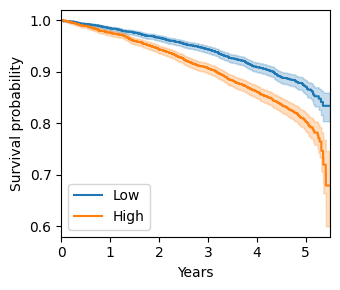

In [37]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt


matched["GAP_group"] = np.where(matched["GAP_corrected"] <= 0, "Low", "High")
matched["GAP_group_bin"] = np.where(matched["GAP_corrected"] <= 0, 0, 1)
matched["GAP_group"].value_counts(dropna=False)


kmf = KaplanMeierFitter()
plt.figure(figsize=(3.5,3.0))

for g in ["Low", "High"]:
  mask = matched["GAP_group"] == g
  df_g = matched.loc[mask, ["time_years", "event"]].dropna()
  kmf.fit(df_g["time_years"], df_g["event"], label=g)
  kmf.plot_survival_function(ci_show=True)

plt.xlabel("Years")
plt.ylabel("Survival probability")
#plt.title("Kaplan–Meier survival by GAP_corrected (≤0 vs >0)")
plt.tight_layout()
plt.xlim([0,5.5])


plt.savefig("Figures/Model-C_kaplan_meier_HC-subjects.pdf", format="pdf", bbox_inches="tight", dpi=300)

plt.show()


#### Log rank

In [38]:
from lifelines.statistics import logrank_test

df_low = matched.loc[matched["GAP_group"]=="Low", ["time_years","event"]].dropna()
df_high = matched.loc[matched["GAP_group"]=="High", ["time_years","event"]].dropna()

lr = logrank_test(
  df_low["time_years"], df_high["time_years"],
  event_observed_A=df_low["event"],
  event_observed_B=df_high["event"]
)

print(f"Log-rank p = {lr.p_value:.3g}")


Log-rank p = 3.97e-14


✅ Guardado: Figures/Model-C_forest-plot_HC.pdf


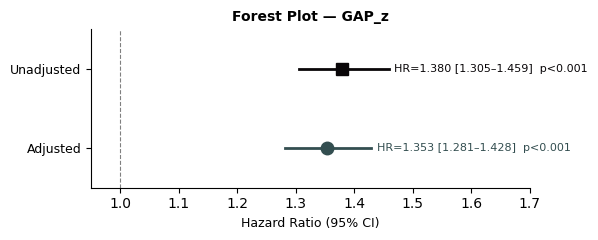

In [39]:
forest_plot_gap(cph_z_unadj, cph_z_adj,
        color_unadj="#090608",
        color_adj="#334E50",
        save_path="Figures/Model-C_forest-plot_HC.pdf")

### Only dem

In [40]:
matched = df_incident.merge(results_GB_orig, on="uid", how="inner", suffixes=("_inc", "_gb"))
matched = matched[matched.anydem == 1].reset_index(drop = True)


matched["date"] = pd.to_datetime(matched["date"], errors="coerce")
matched["death_date"] = pd.to_datetime(matched["death_date"], errors="coerce")
matched["f_date"] = pd.to_datetime(matched["f_date"], errors="coerce")


matched["event"] = matched["death_date"].notna().astype(int)

# End date:
# - if died -> death_date
# - if not died -> f_date (last evaluation)
matched["end_date"] = matched["death_date"].fillna(matched["f_date"])

# (Optional, in case any end_date is empty)
matched["end_date"] = matched["end_date"].fillna(matched["date"].max())

# Time in years
matched["time_years"] = (matched["end_date"] - matched["date"]).dt.days / 365.25

# (Optional) mark invalid times as NaN
matched.loc[matched["time_years"] < 0, "time_years"] = np.nan
matched.loc[matched["time_years"] > 4.5, "time_years"] = np.nan

In [41]:
#a = matched[["date", "death_date", "f_date","end_date", "event"]].dropna(subset = ["f_date"])#['event']#.value_counts()

In [42]:
#a[a.event == 1]

In [43]:
matched.shape

(975, 51)

#### Cox model

In [44]:
from lifelines import CoxPHFitter


df_surv = matched[['time_years', 'event', 'GAP_corrected']].dropna()

cph = CoxPHFitter().fit(df_surv, duration_col='time_years', event_col='event')

out = cph.summary.loc[['GAP_corrected'], ['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']]
out = out.rename(columns={
  'exp(coef)': 'HR',
  'exp(coef) lower 95%': 'CI95_low',
  'exp(coef) upper 95%': 'CI95_high',
  'p': 'p_value'
})
out


,HR,CI95_low,CI95_high,p_value
covariate,,,,
GAP_corrected,1.064942,1.032529,1.098372,0.000066


In [45]:
covars = ['Age', 'Male', 'Education']


In [46]:
from lifelines import CoxPHFitter

def compact_all(cph):
  out = cph.summary.loc[:, ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
  out.columns = ["HR", "CI95_low", "CI95_high", "p_value"]
  return out.sort_values("p_value")




In [47]:
from lifelines import CoxPHFitter

matched["Male"] = (matched["Sex_1F_2M"] == 2).astype(int)



matched["GAP_z"] = (matched["GAP_corrected"] - matched["GAP_corrected"].mean()) / matched["GAP_corrected"].std()

# Unadjusted (by 1 SD)
df_z_unadj = matched[["time_years", "event", "GAP_z"]].dropna()
cph_z_unadj = CoxPHFitter()
cph_z_unadj.fit(df_z_unadj, duration_col="time_years", event_col="event")
print("--- Cox GAP_z (UNADJUSTED) ---")
display(compact_all(cph_z_unadj))

# Adjusted (by 1 SD) using Male dummy
needed_cols_z = ["time_years", "event", "GAP_z"] + covars
df_z_adj = matched[needed_cols_z].dropna()
cph_z_adj = CoxPHFitter()
cph_z_adj.fit(df_z_adj, duration_col="time_years", event_col="event")
print("\n\n--- Cox GAP_z (ADJUSTED) ---")
display(compact_all(cph_z_adj))


#### Survive curve

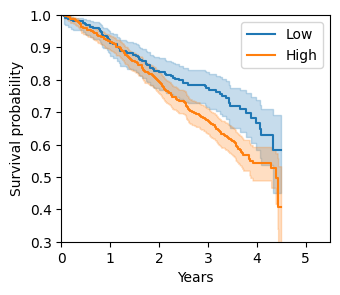

In [48]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt


matched["GAP_group"] = np.where(matched["GAP_corrected"] <= 0, "Low", "High")
matched["GAP_group_bin"] = np.where(matched["GAP_corrected"] <= 0, 0, 1)
matched["GAP_group"].value_counts(dropna=False)


kmf = KaplanMeierFitter()
plt.figure(figsize=(3.5,3.0))

for g in ["Low", "High"]:
  mask = matched["GAP_group"] == g
  df_g = matched.loc[mask, ["time_years", "event"]].dropna()
  kmf.fit(df_g["time_years"], df_g["event"], label=g)
  kmf.plot_survival_function(ci_show=True)

plt.xlabel("Years")
plt.ylabel("Survival probability")
#plt.title("Kaplan–Meier survival by GAP_corrected (≤0 vs >0)")
plt.tight_layout()
plt.xlim([0,5.5])
plt.ylim([0.3, 1])


plt.savefig("Figures/Model-C_kaplan_meier_Dem-subjects.pdf", format="pdf", bbox_inches="tight", dpi=300)

plt.show()


#### Log rank

In [49]:
from lifelines.statistics import logrank_test

df_low = matched.loc[matched["GAP_group"]=="Low", ["time_years","event"]].dropna()
df_high = matched.loc[matched["GAP_group"]=="High", ["time_years","event"]].dropna()

lr = logrank_test(
  df_low["time_years"], df_high["time_years"],
  event_observed_A=df_low["event"],
  event_observed_B=df_high["event"]
)

print(f"Log-rank p = {lr.p_value:.3g}")


Log-rank p = 0.00514


✅ Guardado: Figures/Model-C_forest-plot_Dementia.pdf


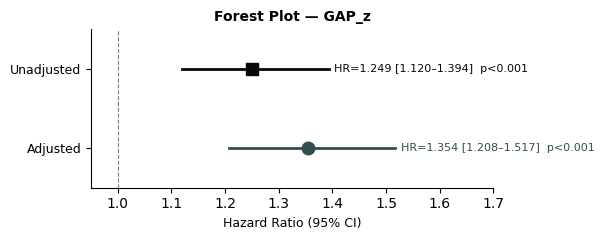

In [50]:
forest_plot_gap(cph_z_unadj, cph_z_adj,
        color_unadj="#090608",
        color_adj="#334E50",
        save_path="Figures/Model-C_forest-plot_Dementia.pdf")

# Longitudinal analysis

## Matched BBAGw1 vs BBAGw2

In [27]:
results_GB_orig.columns

Index(['particid', 'householdid', 'centreid', 'date', 'Age', 'anydem',
       'dsmcase', 'cogcase', 'mci', 'Countries', 'Angina', 'Arthritis',
       'Ataxia', 'Audition_problems', 'Back_diseases', 'Bradykinesia',
       'Breath_problems', 'Breathlessness', 'Cough', 'Education',
       'Exercise_increase', 'Family_dementia_any', 'Heart_Disease_1Y_0N',
       'Hypertension_1Y_0N', 'Limiting_illnesses', 'Medications_1Y_0N', 'Pain',
       'Physical_activities', 'Sex_1F_2M', 'Skin_disorder', 'Vision_problems',
       'Walk_1Y_0N', 'orthostatic_drop', 'pulse_pressure', 'y_labels',
       'y_pred', 'GAP', 'GAP_corrected', 'y_pred_corrected', 'uid'],
      dtype='object')

In [28]:
results_GB_incident = pd.read_parquet('Results/wo-used-diag-vars-and-funct-vars_all-subjects-Incidence.parquet')


results_GB_incident["uid"] = make_uid(results_GB_incident)

matched = results_GB_incident.merge(results_GB_orig, on="uid", how="inner", suffixes=("_w2", "_w1"))

matched = df_incident[["uid", "death_date" , "f_date"]].merge(matched, on="uid", how="inner")


#matched = matched.merge(results_GB_incident[['uid', 'GAP_corrected']], on="uid", how="inner", suffixes=("_gb", "_inc"))

In [29]:
matched["date_w1"] = pd.to_datetime(matched["date_w1"], errors="coerce")
matched["death_date"] = pd.to_datetime(matched["death_date"], errors="coerce")
matched["f_date"] = pd.to_datetime(matched["f_date"], errors="coerce")


matched["event"] = matched["death_date"].notna().astype(int)

# End date:
# - if died -> death_date
# - if not died -> f_date (last evaluation)
matched["end_date"] = matched["death_date"].fillna(matched["f_date"])

# (Optional, in case any end_date is empty)
#matched["end_date"] = matched["end_date"].fillna(matched["date"].max())

# Time in years
matched["time_years"] = (matched["end_date"] - matched["date_w1"]).dt.days / 365.25
matched["time_day"] = (matched["end_date"] - matched["date_w1"]).dt.days
# (Optional) mark invalid times as NaN
matched.loc[matched["time_years"] < 0, "time_years"] = np.nan

In [30]:
matched["GAP_corrected_w2_time_c"] = matched["GAP_corrected_w2"] / matched["time_day"]


In [31]:
matched["time_years"].describe()

count    6629.000000
mean        4.137488
std         0.966352
min         0.930869
25%         3.258042
50%         4.145106
75%         4.917180
max         7.425051
Name: time_years, dtype: float64

In [32]:
def plot_pred_vs_true_density(df_final, x , y):
  import numpy as np
  import matplotlib.pyplot as plt
  from scipy.stats import gaussian_kde
  from scipy.stats import linregress

  [y_true_all, y_pred_all] = df_final[x], df_final[y]

  xy = np.vstack([y_true_all, y_pred_all]) 
  density = gaussian_kde(xy)(xy)      

  sizes = 100 * (density / density.max()) 



  scatter = plt.scatter(y_true_all, y_pred_all, c=density, s=sizes, cmap='gray', alpha=0.6)
  #plt.plot([min(y_true_all), max(y_true_all)], [min(y_true_all), max(y_true_all)], 'k--')
  slope, intercept, r_value, p_value, std_err = linregress(df_final[x], df_final[y])
  plt.plot(df_final[x], intercept + slope * df_final[x], color='black')
  plt.xlabel(x)
  plt.ylabel(y)

  r_value1 = np.abs(r_value)
  d_cohen = (2 * r_value1) / np.sqrt(1 - r_value1**2)

  plt.title( f'd-cohen={d_cohen:.2f} \nr={r_value:.2f} p={p_value:.2e}')



  return None

# -----------------------------
# Remove outliers using IQR (per variable)
# -----------------------------
def remove_iqr_outliers(df, cols, k=1.5):
  mask = np.ones(len(df), dtype=bool)
  for c in cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    high = q3 + k * iqr
    mask &= df[c].between(low, high)
  return df.loc[mask]

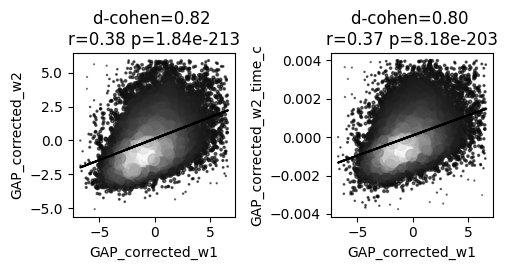

In [33]:
plt.figure(figsize=(5, 2.8))
plt.subplot(1,2,1)

ycol = "GAP_corrected_w2"
xcol = "GAP_corrected_w1"

d = matched[[xcol, ycol]].dropna().copy()

d = remove_iqr_outliers(d, [xcol, ycol], k=1.5)

plot_pred_vs_true_density(d, "GAP_corrected_w1", "GAP_corrected_w2")



ycol = "GAP_corrected_w2_time_c"
xcol = "GAP_corrected_w1"

d = matched[[xcol, ycol]].dropna().copy()

d = remove_iqr_outliers(d, [xcol, ycol], k=1.5)

plt.subplot(1,2,2)
plot_pred_vs_true_density(d, "GAP_corrected_w1", "GAP_corrected_w2_time_c")

plt.tight_layout()

plt.savefig("Figures/Model-C_scatterplot-long.pdf", format="pdf", bbox_inches="tight", dpi=300)


In [52]:
matched.columns

Index(['uid', 'death_date', 'f_date', 'particid_w2', 'householdid_w2',
       'centreid_w2', 'date_w2', 'Age_w2', 'anydem_w2', 'dsmcase_w2',
       'cogcase_w2', 'mci_w2', 'Countries_w2', 'Audition_problems_w2',
       'Education_w2', 'Physical_activities_w2', 'Sex_1F_2M_w2',
       'Walk_1Y_0N_w2', 'y_labels_w2', 'y_pred_w2', 'GAP_w2',
       'GAP_corrected_w2', 'y_pred_corrected_w2', 'particid_w1',
       'householdid_w1', 'centreid_w1', 'date_w1', 'Age_w1', 'anydem_w1',
       'dsmcase_w1', 'cogcase_w1', 'mci_w1', 'Countries_w1', 'Angina',
       'Arthritis', 'Ataxia', 'Audition_problems_w1', 'Back_diseases',
       'Bradykinesia', 'Breath_problems', 'Breathlessness', 'Cough',
       'Education_w1', 'Exercise_increase', 'Family_dementia_any',
       'Heart_Disease_1Y_0N', 'Hypertension_1Y_0N', 'Limiting_illnesses',
       'Medications_1Y_0N', 'Pain', 'Physical_activities_w1', 'Sex_1F_2M_w1',
       'Skin_disorder', 'Vision_problems', 'Walk_1Y_0N_w1', 'orthostatic_drop',
       'puls

## Matched BBAGw1 vs Biologic

In [53]:
import pyreadstat

df_bio, metadata = pyreadstat.read_sav("Data/1066Herna_DAC_Blood/1066Herna_DAC_Blood/blood_sample_data1_0.sav")


df_bio["uid"] = make_uid(df_bio, hh_col="HOUSEID", p_col="PARTICID")


matched = df_bio.merge(results_GB_orig, on="uid", how="inner", suffixes=("_bio", "_w1"))



In [54]:
results = []

for i in ['hb', 'hct', 'mchc', 'mch', 'mcv',
    'mcvcat', 'RBC', 'WBC', 'platelet', 'anaemia', 'anaemia_mcvcat',
    'glucose', 'diabetes', 'creat', 'protein', 'albumin', 'globulin',
    'chol_tot', 'triglic', 'vldl', 'hdl', 'ldl', 'ms_glucose', 'ms_trig',
    'ms_hdl', 'ms_chol', 'ms_lipid', 'blood_test', 'ms_hyper', 'ms_waist',
    'ms_criteria', 'met_synd', 'ms_hyper_told', 'ms_glucose_told',
    'ms_mv_told', 'ms_criteria_told', 'met_synd_told', 'diabetes_total',
    'diabetes_summary', 'diabetes_aware', 'diabetes_control', 'arm_sd',
    'alb_sd', 'creat_sd', 'illnogut', 'albumin_low', 'nomeat', 'site_serv',
    'B12', 'Folate', 'Hcy', 'Hgb1la', 'diabetes_hbA1c', 'INSULINL', 'BUN']:
  try:
    c = matched[i].corr(matched['GAP_corrected'])
    if(np.abs(c)>0.01):
      
      print(i, c, dict_meta[i])#, '\t\t\t', dict_df.mine.get_metadata(i)['Label'].values[0])
      results.append({
        'variable': i,
        'correlation': c
      })
  except:
    print(i, c)
    results.append({
        'variable': i,
        'correlation': np.nan
      })

mch -0.011093856010076075
mcv 0.027344470592627547
RBC -0.023693154640358663
platelet 0.023209104723312175
anaemia 0.017819172715611984
creat -0.010647499382281305
chol_tot 0.024886176331024582
vldl -0.013444754617466121
ldl 0.025570482449410348
ms_trig -0.012766966863832026
ms_chol 0.02810966632410041
blood_test -0.017039198531701286
ms_hyper 0.03233072890638947
ms_criteria 0.013099641376932744
met_synd 0.012233372404165426
ms_hyper_told 0.02343024837903326
ms_mv_told 0.01137805248317873
arm_sd -0.03938821341596219
site_serv -0.02874815736136885
B12 -0.013796144917410658
Folate -0.04198828644208062
diabetes_hbA1c -0.018097946867746625
INSULINL 0.050251768444965955
BUN -0.018190636553577368


KeyError: 'GAP_corrected_w1'

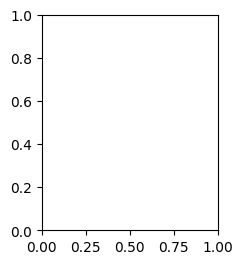

In [55]:
plt.figure(figsize=(5, 2.8))
plt.subplot(1,2,1)
plot_pred_vs_true_density(matched, "GAP_corrected_w1", "GAP_corrected_w2")

ycol = "GAP_corrected_w2_time_c"
xcol = "GAP_corrected_w1"

d = matched[[xcol, ycol]].dropna().copy()

d = remove_iqr_outliers(d, [xcol, ycol], k=1.5)

plt.subplot(1,2,2)
plot_pred_vs_true_density(d, "GAP_corrected_w1", "GAP_corrected_w2_time_c")

plt.tight_layout()

## MCI Rev test

In [ ]:
results_GB_incident = pd.read_parquet('Results/all-vars_all-subjects-Incidence.parquet')


results_GB_incident["uid"] = make_uid(results_GB_incident)


In [ ]:
matched = df_incident.merge(results_GB_orig, on="uid", how="inner", suffixes=("_inc", "_gb"))
matched = matched.merge(results_GB_incident[['uid', 'GAP_corrected']], on="uid", how="inner", suffixes=("_gb", "_inc"))

In [ ]:
matched;
# 0 -> 1 (MCI incidence)
n_0_to_1 = ((matched["mci"] == 0) & (matched["f_mci"] == 1)).sum()

# 1 -> 0 (reversion)
n_1_to_0 = ((matched["mci"] == 1) & (matched["f_mci"] == 0)).sum()

# Stay the same
n_0_to_0 = ((matched["mci"] == 0) & (matched["f_mci"] == 0)).sum()
n_1_to_1 = ((matched["mci"] == 1) & (matched["f_mci"] == 1)).sum()

print("0 → 1 (no MCI → MCI):", n_0_to_1)
print("1 → 0 (MCI → no MCI):", n_1_to_0)
print("0 → 0 (stable no MCI):", n_0_to_0)
print("1 → 1 (stable MCI):", n_1_to_1)

In [ ]:
df = matched.copy()

df["clinical_diagnosis"] = np.nan

#df.loc[(df["mci"] == 0) & (df["f_mci"] == 0) & (df["anydem"] == 0), "clinical_diagnosis"] = "CN" #CN_stable_0to0
df.loc[(df["mci"] == 0) & (df["f_mci"] == 1), "clinical_diagnosis"] = "MCIConv" #MCI_incidence_0to1
df.loc[(df["mci"] == 1) & (df["f_mci"] == 0)& (df["anydem"] == 0), "clinical_diagnosis"] = "MCIRev" #MCI_reversion_1to0
#df.loc[(df["mci"] == 0) & (df["anydem"] == 1), "clinical_diagnosis"] = "CN2Dem" #AnyDem_0to1

# Keep only those groups
df_g = df[["GAP_corrected_gb", "GAP_corrected_inc","clinical_diagnosis"]].dropna()

In [ ]:
df_g['Delta'] = df_g["GAP_corrected_gb"] - df_g["GAP_corrected_inc"]

In [ ]:
import pandas as pd
import numpy as np

d = df_g[["GAP_corrected_gb", "GAP_corrected_inc", 'Delta', "clinical_diagnosis"]].dropna().copy()

# y=1 if MCIConv, y=0 if MCIRev (change order if preferred otherwise)
d["y"] = (d["clinical_diagnosis"] == "MCIConv").astype(int)

d["y"].value_counts()


In [ ]:
import statsmodels.api as sm

X = d[["Delta"]]
X = sm.add_constant(X)
y = d["y"]

m = sm.Logit(y, X).fit(disp=False)
print(m.summary())

# Odds Ratios (OR) + CI95%
params = m.params
conf = m.conf_int()
or_table = pd.DataFrame({
  "OR": np.exp(params),
  "CI95_low": np.exp(conf[0]),
  "CI95_high": np.exp(conf[1]),
  "p": m.pvalues
})
or_table


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

X = d[["GAP_corrected_gb", "GAP_corrected_inc"]].values
y = d["y"].values

pipe = Pipeline([
  ("scaler", StandardScaler()),
  ("lr", LogisticRegression(max_iter=2000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Out-of-fold probabilities
y_prob = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
y_hat = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y, y_prob)
acc = accuracy_score(y, y_hat)
cm = confusion_matrix(y, y_hat)

auc, acc, cm


# Dementia progression

In [1]:
matched = df_incident.merge(results_GB_orig, on="uid", how="inner", suffixes=("_inc", "_gb"))


NameError: name 'df_incident' is not defined

In [ ]:
# 0 -> 1 (MCI incidence)
n_0_to_1 = ((matched["mci"] == 0) & (matched["f_mci"] == 1)).sum()

# 1 -> 0 (reversion)
n_1_to_0 = ((matched["mci"] == 1) & (matched["f_mci"] == 0)).sum()

# Stay the same
n_0_to_0 = ((matched["mci"] == 0) & (matched["f_mci"] == 0)).sum()
n_1_to_1 = ((matched["mci"] == 1) & (matched["f_mci"] == 1)).sum()

print("0 → 1 (no MCI → MCI):", n_0_to_1)
print("1 → 0 (MCI → no MCI):", n_1_to_0)
print("0 → 0 (stable no MCI):", n_0_to_0)
print("1 → 1 (stable MCI):", n_1_to_1)


In [ ]:
transition_table = pd.crosstab(
  matched["mci"],
  matched["f_mci"],
  rownames=["MCI wave 1"],
  colnames=["MCI wave 2"]
)

transition_table


In [ ]:
changed = matched[matched["mci"] != matched["f_mci"]]
changed[['GAP_corrected', 'mci', 'f_mci', 'anydem']]

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# --------------------------------------------------
# Utilities
# --------------------------------------------------

def remove_outliers_iqr(df, col, iqr_k=1.5):
  s = pd.to_numeric(df[col], errors="coerce")
  q1 = s.quantile(0.25)
  q3 = s.quantile(0.75)
  iqr = q3 - q1
  low = q1 - iqr_k * iqr
  high = q3 + iqr_k * iqr
  return df.loc[(s >= low) & (s <= high)].copy()


def cliffs_delta(x, y):
  x = pd.to_numeric(pd.Series(x).dropna(), errors="coerce").values
  y = pd.to_numeric(pd.Series(y).dropna(), errors="coerce").values
  nx, ny = len(x), len(y)
  if nx == 0 or ny == 0:
    return np.nan
  diffs = x[:, None] - y[None, :]
  n_greater = np.sum(diffs > 0)
  n_less = np.sum(diffs < 0)
  return float((n_greater - n_less) / (nx * ny))


def permutation_pvalue(x, y, n_perm=10000, seed=42):
  """Two-sided permutation test for mean difference"""
  rng = np.random.default_rng(seed)
  x = np.array(pd.Series(x).dropna())
  y = np.array(pd.Series(y).dropna())
  if len(x) == 0 or len(y) == 0:
    return np.nan

  obs_diff = np.abs(np.mean(x) - np.mean(y))
  combined = np.concatenate([x, y])
  nx = len(x)
  count = 0

  for _ in range(n_perm):
    rng.shuffle(combined)
    x_perm, y_perm = combined[:nx], combined[nx:]
    diff = np.abs(np.mean(x_perm) - np.mean(y_perm))
    if diff >= obs_diff:
      count += 1

  return count / n_perm


def chunk_list(lst, n):
  for i in range(0, len(lst), n):
    yield lst[i:i + n]


# --------------------------------------------------
# Main plotting + stats function
# --------------------------------------------------

def plot_gap_by_diagnosis_clean_wrap(
  df,
  gap_col,
  diagnosis_list,
  thresholds=(0.1, 0.5, 1.0, 1.5),
  per_line=3,
  title_fontsize=8,
  n_perm=10000
):

  # --- Build original grouped data ---
  group_data_orig = {}
  for diag in diagnosis_list:
    sub = df[df["clinical_diagnosis"] == diag][[gap_col]].copy()
    sub["Origen"] = diag
    group_data_orig[diag] = sub

  # --- All unique pairwise comparisons ---
  all_pairs = [
    (diagnosis_list[i], diagnosis_list[j])
    for i in range(len(diagnosis_list))
    for j in range(i + 1, len(diagnosis_list))
  ]

  results_table = []

  fig, axes = plt.subplots(2, 2, figsize=(7.0, 8.0), sharey=True)
  axes = axes.flatten()

  # --- Loop over IQR thresholds ---
  for ax, iqr_k in zip(axes, thresholds):

    group_data_clean = {
      diag: remove_outliers_iqr(group_data_orig[diag], gap_col, iqr_k)
      for diag in diagnosis_list
    }

    title_lines = [f"IQR = {iqr_k}"]

    for a, b in all_pairs:
      x = group_data_clean[a][gap_col]
      y = group_data_clean[b][gap_col]

      n_a = x.dropna().shape[0]
      n_b = y.dropna().shape[0]

      dval = cliffs_delta(x, y)
      pval = permutation_pvalue(x, y, n_perm=n_perm)

      results_table.append([
        iqr_k, a, b, n_a, n_b, dval, pval
      ])

      title_lines.append(f"{a}–{b}: d={dval:.2f}")

    # --- Title wrapping ---
    wrapped = [" | ".join(chunk) for chunk in chunk_list(title_lines, per_line)]
    ax.set_title("\n".join(wrapped), fontsize=title_fontsize)

    # --- Plot ---
    combined = pd.concat(
      [group_data_clean[d] for d in diagnosis_list],
      ignore_index=True
    )

    sns.violinplot(
      data=combined,
      x="Origen",
      y=gap_col,
      order=diagnosis_list,
      ax=ax,
      #inner="quartile",
      #cut=0
    )

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("")
    ax.set_ylabel(gap_col)

  plt.tight_layout()

  # --- Results dataframe ---
  results_df = pd.DataFrame(
    results_table,
    columns=[
      "IQR_k",
      "Group1",
      "Group2",
      "n_group1",
      "n_group2",
      "CliffsDelta",
      "p_value"
    ]
  )

  return fig, axes, results_df


In [ ]:
import numpy as np
import pandas as pd

df = matched.copy()

df["clinical_diagnosis"] = np.nan

df.loc[(df["mci"] == 0) & (df["f_mci"] == 0) & (df["anydem"] == 0), "clinical_diagnosis"] = "CN" #CN_stable_0to0
df.loc[(df["mci"] == 0) & (df["f_mci"] == 1), "clinical_diagnosis"] = "MCIConv" #MCI_incidence_0to1
df.loc[(df["mci"] == 1) & (df["f_mci"] == 0)& (df["anydem"] == 0), "clinical_diagnosis"] = "MCIRev" #MCI_reversion_1to0
df.loc[(df["mci"] == 0) & (df["anydem"] == 1), "clinical_diagnosis"] = "CN2Dem" #AnyDem_0to1

# Keep only those groups
df_g = df[["GAP_corrected", "clinical_diagnosis"]].dropna()


In [ ]:
Counter(df_g["clinical_diagnosis"])

In [ ]:
# List of diagnoses to include
diagnosis_list = ["CN", "MCIConv", "CN2Dem"]

# Use the function
a = plot_gap_by_diagnosis_clean_wrap(
  df_g,
  gap_col="GAP_corrected",
  diagnosis_list=diagnosis_list
);

In [ ]:
stats_ = a[2][a[2]['IQR_k'] == 0.5]
stats_ = stats_.copy()
#stats_['p_value'] = stats_['p_value']
stats_['CliffsDelta'] = stats_['CliffsDelta'].abs().round(2)
stats_

In [ ]:
df_g

In [ ]:
changed.dropna(subset=['f_mci'])